# Spatial BMCD — pipeline notebook

Clean refactor of `spatial_analysis_original.ipynb`. All function bodies live in:

- [spatial_bmcd/spatial_model.py](spatial_model.py) — single-site integration, spatial Markov step, pairwise composite likelihood, MLE, ECAD I/O.
- [spatial_bmcd/spatial_plotting.py](spatial_plotting.py) — station map, tail-probability illustration, Gaussian-field illustration.

This notebook reuses the single-site fit outputs produced by [`notebooks_article_pipeline/01_prepare_data_and_fit_distributions.ipynb`](../article_code/notebooks_article_pipeline/01_prepare_data_and_fit_distributions.ipynb). Equations referenced below are from [spatial_analysis_article.tex](spatial_analysis_article.tex).

## Imports & data loading

In [2]:
import sys, pathlib
_HERE = pathlib.Path.cwd().resolve()
_REPO_ROOT = next(
    (p for p in (_HERE, *_HERE.parents) if (p / "article_code").is_dir()),
    None,
)
if _REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root containing 'article_code/' from {_HERE}")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from article_code.util_files import config
from spatial_bmcd.spatial_model import (
    prepare_station_fit_table,
    build_dict_model_params,
    run_simulation_mle_experiment,
    load_all_station_rr,
    build_joint_df_occurrence_from_raw_data,
    history_from_Rbin_drop_ambiguous_spell_after_nan,
    split_history_by_year,
    mle_sigma_pairwise,
    mle_sigma_pairwise_histories,
    simulate_fitted_model,
)
from spatial_bmcd.spatial_plotting import (
    plot_stations_geomap,
    plot_stations_map,
    plot_tail_probability_illustration,
    plot_gaussian_field_with_thresholds,
)

In [3]:
# Load single-site outputs produced by notebook 01.
base_filename = (
    f"ecad_data_south_europe_filtered_after_{config.START_YEAR}"
    f"_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json"
)
with open(config.EXPORTS_JSON_DIR / base_filename) as fh:
    spells = json.load(fh)

stations_metadata = pd.read_csv(config.STATION_METADATA_CSV)
stations_used = stations_metadata[stations_metadata["city"].isin(spells.keys())]

fit_folder = (
    config.RESULTS_FIT_DIR
    / f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}"
)
df_fit_dry = pd.read_csv(fit_folder / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv")
df_fit_wet = pd.read_csv(fit_folder / "wet_spell_fit_mixt_geomresult_fit_parameters.csv")
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s: s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s: s.split()[-1])

print(f"{len(spells)} stations in spells JSON; {len(stations_used)} in metadata; "
      f"{df_fit_dry['city'].nunique()} cities in dry fit, "
      f"{df_fit_wet['city'].nunique()} in wet fit")

209 stations in spells JSON; 209 in metadata; 209 cities in dry fit, 209 in wet fit


## Map of cities Europe

Select the Iberian (PT, ES) stations in spring, normalise their coordinates onto $[0,1]^2$ for the spatial covariance, and show them on a map.

In [4]:
COUNTRIES = ["PT", "ES"]
SEASON = "spring"

df_fit_dry_sub, df_fit_wet_sub = prepare_station_fit_table(
    df_fit_dry, df_fit_wet, stations_used,
    countries=COUNTRIES, season=SEASON,
)
print(f"{len(df_fit_dry_sub)} stations kept for season={SEASON}, countries={COUNTRIES}")

plot_stations_geomap(df_fit_dry_sub).show()
# plot_stations_map(df_fit_dry_sub, color_col="xi");

35 stations kept for season=spring, countries=['PT', 'ES']


## Recover exit probabilities from the single-site model

For every station, build the season-specific exit-probability closures $q^{(0)}(d)$ and $q^{(1)}(d)$ using the fitted hdeGPD (dry) and mixture-geometric (wet) parameters and the $f_1$ proportion. See Eq. (1) of the article.

In [5]:
dict_model_params = build_dict_model_params(
    df_fit_dry_sub, df_fit_wet_sub, spells, season=SEASON,
)
print(f"Built model parameters for {len(dict_model_params)} stations")

# Sanity check: q^(0)(1), q^(0)(5), q^(1)(1) for the first station
city0 = next(iter(dict_model_params))
p = dict_model_params[city0]
print(f"{city0}: q_dry(1)={p['q_d_dry_function'](1):.3f}, "
      f"q_dry(5)={p['q_d_dry_function'](5):.3f}, "
      f"q_dry(20)={p['q_d_dry_function'](20):.3f}, --- "
      f"q_wet(1)={p['q_d_wet_function'](1):.3f}",
      f"q_wet(5)={p['q_d_wet_function'](5):.3f}",
      f"q_wet(20)={p['q_d_wet_function'](20):.3f}")

100%|██████████| 35/35 [00:00<00:00, 272.13it/s]

Built model parameters for 35 stations
ALACANT/ALICANTE: q_dry(1)=0.142, q_dry(5)=0.101, q_dry(20)=0.074, --- q_wet(1)=0.538 q_wet(5)=0.521 q_wet(20)=0.441


## Maximum-likelihood estimation on simulated data

Sanity-check the pairwise composite likelihood by simulating spatial histories with a known $\sigma$ and recovering it via `run_simulation_mle_experiment`. Each row of the returned DataFrame is one independent simulation.

In [6]:
SIGMA_TRUE = 0.2
EXPERIMENTS = [
    dict(nb_stations=5,                       nb_steps=200, nb_estimations=5),
    dict(nb_stations=len(dict_model_params),  nb_steps=100, nb_estimations=3),
]

results = []
for cfg in EXPERIMENTS:
    df = run_simulation_mle_experiment(
        dict_model_params, sigma_true=SIGMA_TRUE, **cfg,
    )
    df["cfg"] = f"J={cfg['nb_stations']}, T={cfg['nb_steps']}"
    results.append(df)
    print(f"\n{df['cfg'].iloc[0]} -- sigma_true={SIGMA_TRUE}")
    print(df[["i", "sigma_hat", "ll_hat"]].round(4).to_string(index=False))

results_df = pd.concat(results, ignore_index=True)


J=5, T=200 -- sigma_true=0.2
 i  sigma_hat     ll_hat
 0     0.1090 -1701.3496
 1     0.2467 -1658.5771
 2     0.2507 -1881.6934
 3     0.1828 -1794.6993
 4     0.2405 -1826.8213

J=35, T=100 -- sigma_true=0.2
 i  sigma_hat      ll_hat
 0     0.1786 -53321.8490
 1     0.1871 -48041.1572
 2     0.1857 -53150.6704


## Robustness to missing data

Same experiment, but with 10% of stations randomly masked at every time step. The pairwise likelihood is NaN-aware, so the estimator should still recover $\sigma$.

In [7]:
df_nan = run_simulation_mle_experiment(
    dict_model_params, sigma_true=SIGMA_TRUE,
    nb_stations=5, nb_steps=100, nb_estimations=5,
    inject_nan_frac=0.10,
)
print(f"sigma_true={SIGMA_TRUE}, frac_nan=0.10")
print(df_nan[["i", "sigma_hat", "ll_hat", "mean_nb_obs_stations"]].round(4).to_string(index=False))

sigma_true=0.2, frac_nan=0.10
 i  sigma_hat    ll_hat  mean_nb_obs_stations
 0     0.0804 -530.6997                   4.0
 1     0.3965 -478.4371                   4.0
 2     0.2760 -558.5320                   4.0
 3     0.1477 -538.5379                   4.0
 4     0.1261 -510.6280                   4.0


## Real-data estimation on ECAD

Load daily rainfall (`RR`) for every selected station, threshold to dry/wet occurrences, split into per-year histories of one season, and fit a single $\hat{\sigma}$ by summing the pairwise composite likelihood across years.

In [8]:
# Default to the in-repo ECAD subset used by notebook 01.
# Point to a different folder (with the same df_candidates_kept.csv layout) to use new data.
RAW_DATA_DIR = config.ECAD_RAW_DIR
YEAR_MIN, YEAR_MAX = 1980, 2020

stations_to_get = sorted(dict_model_params.keys())
dfs_by_city = load_all_station_rr(
    data_dir=RAW_DATA_DIR, stations_to_get=stations_to_get, verbose=True,
)
stations_to_get = [c for c in stations_to_get if c in dfs_by_city]
print(f"Loaded {len(dfs_by_city)} stations")

Loading station RR files: 100%|██████████| 247/247 [00:11<00:00, 22.26it/s, value=VALLE DE HECHO  HECHO -- 273342]        

Finished RR load -- Rejected 0 station files
Loaded 35 stations


Rbin shape: (3772, 35) (days x stations) over spring 1980-2020


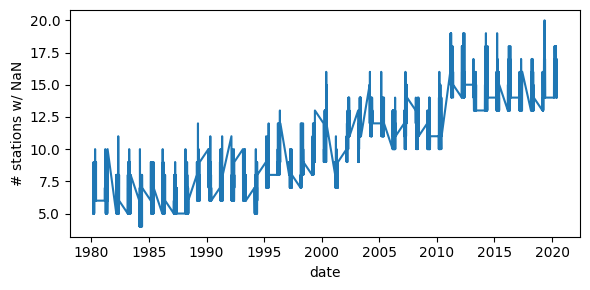

In [9]:
Rbin = build_joint_df_occurrence_from_raw_data(
    dfs_by_city, season=SEASON, station_names=stations_to_get,
    wet_day_threshold=float(config.WET_DAY_THRESHOLD),
)
Rbin = Rbin.loc[(Rbin.index.year >= YEAR_MIN) & (Rbin.index.year <= YEAR_MAX)]
print(f"Rbin shape: {Rbin.shape} (days x stations) over {SEASON} {YEAR_MIN}-{YEAR_MAX}")

# Diagnostic: number of stations with no observation per day
nb_missing = Rbin.isna().sum(axis=1)
plt.figure(figsize=(6, 3))
plt.plot(nb_missing.index, nb_missing.values)
plt.ylabel("# stations w/ NaN"); plt.xlabel("date"); plt.tight_layout();

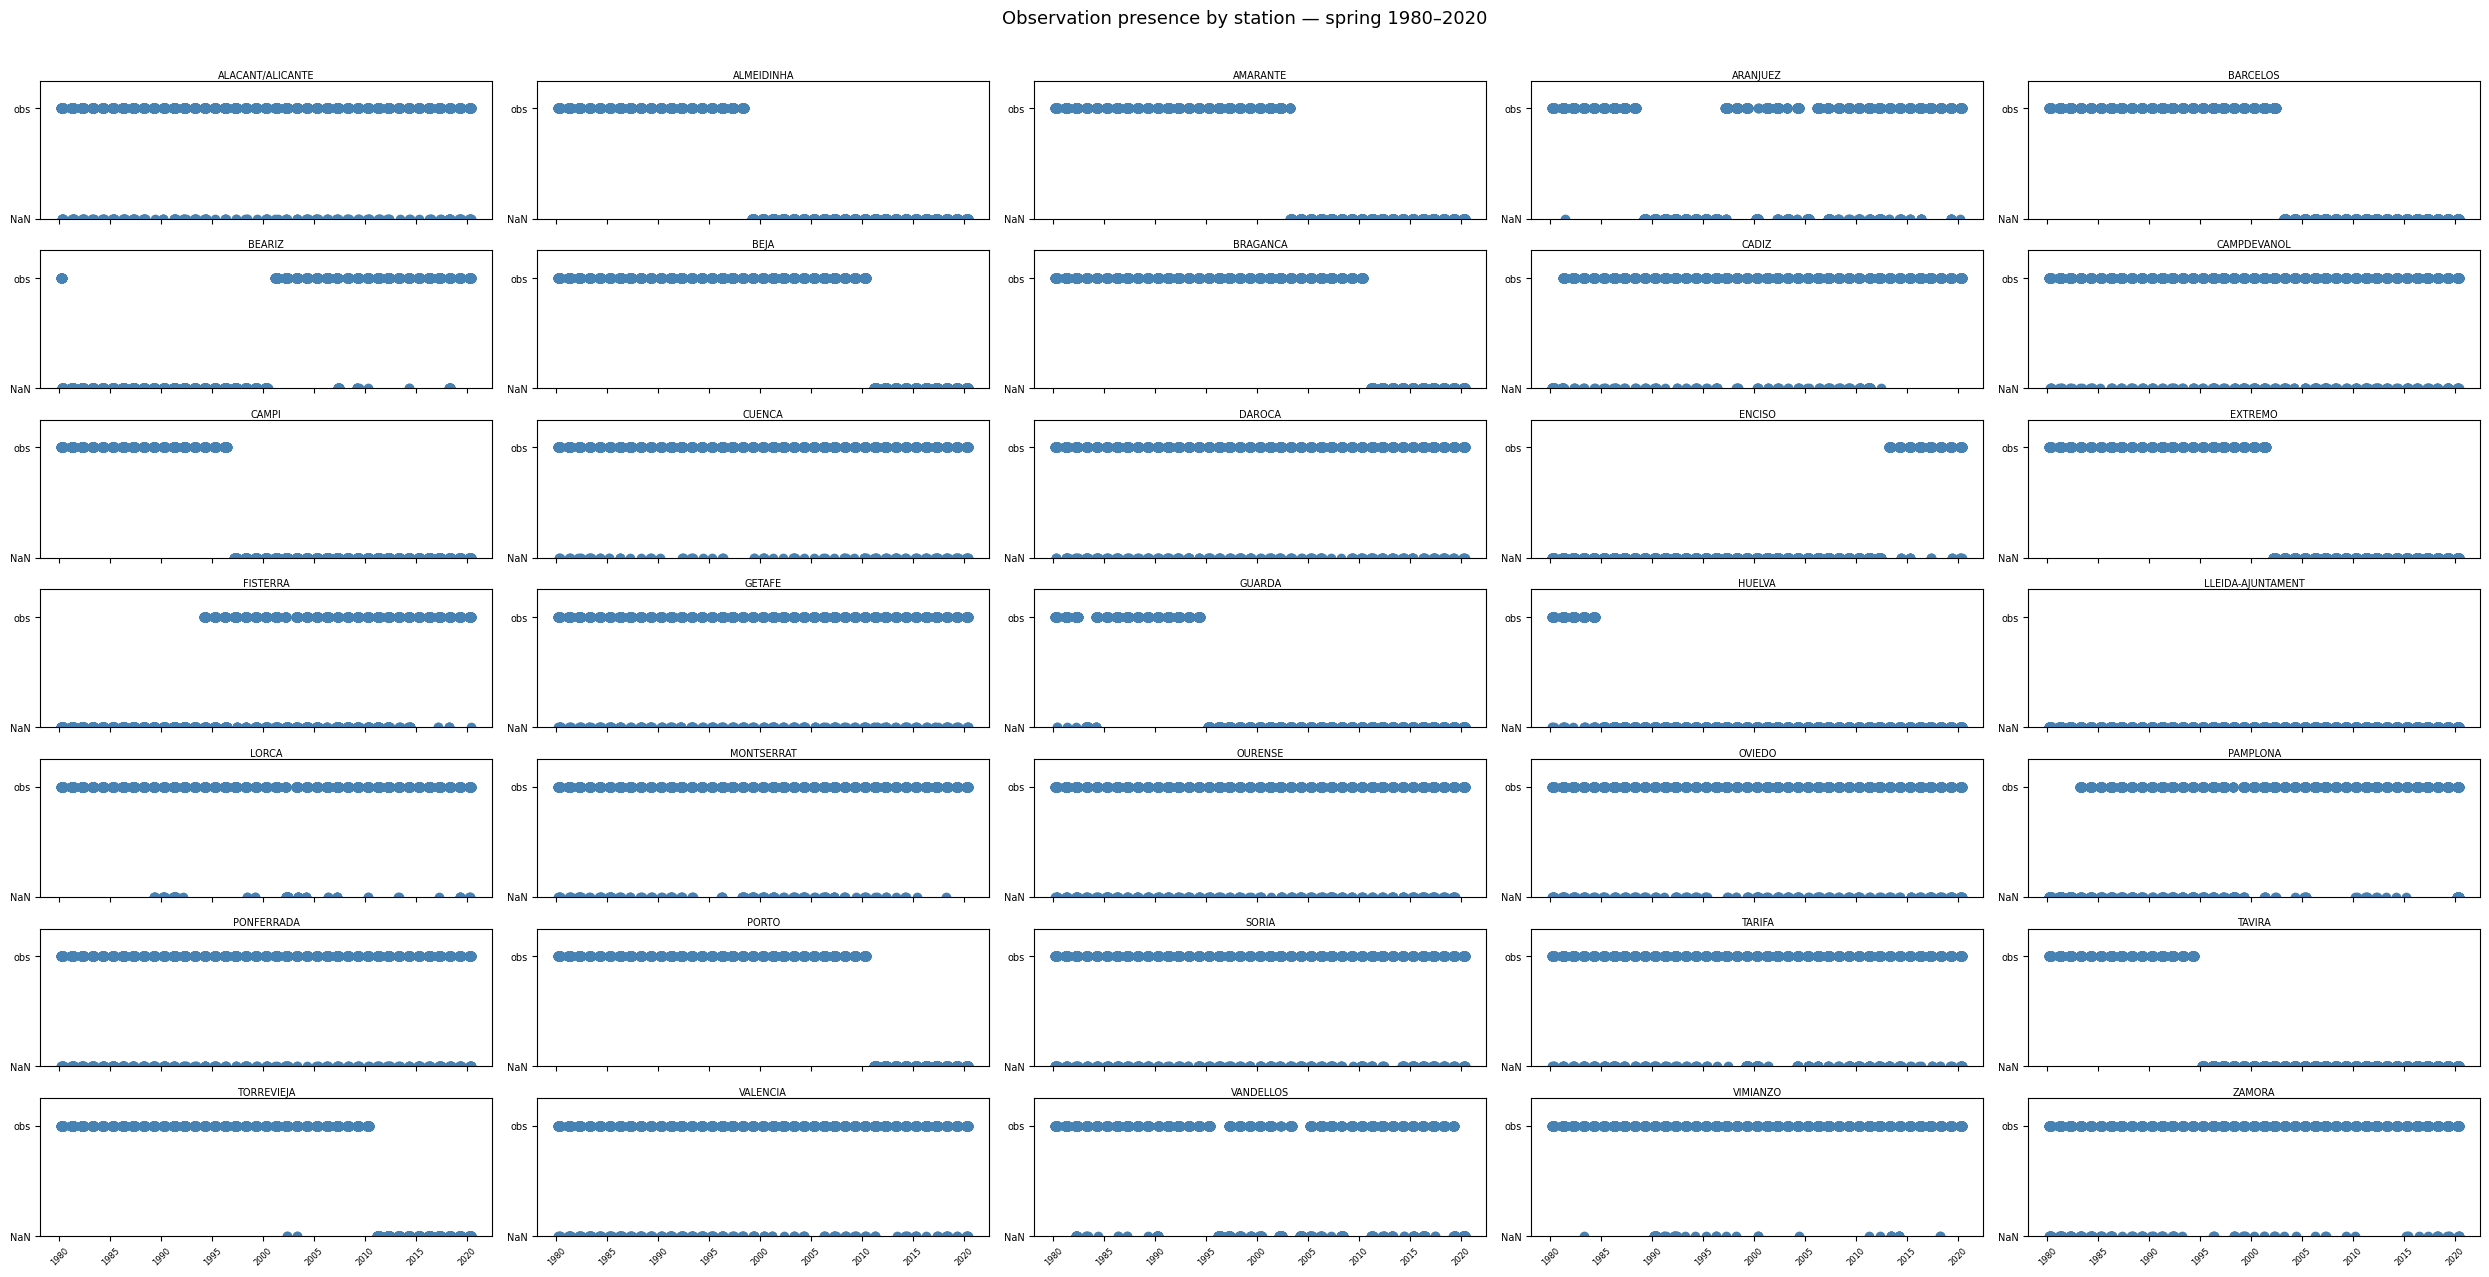

In [10]:
# Per-station missing-data overview: 1 = observed, 0 = missing
n_stations = len(Rbin.columns)
n_cols = 5
n_rows = (n_stations + n_cols - 1) // n_cols          # ceil division → 7 rows

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 5, n_rows * 1.8),
    sharex=True,
)
axes_flat = axes.flatten()

for ax, station in zip(axes_flat, Rbin.columns):
    observed = (~Rbin[station].isna()).astype(int)
    ax.scatter(observed.index, observed.values, color="steelblue")
    ax.set_ylim(0, 1.25)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["NaN", "obs"], fontsize=7)
    ax.set_title(station, fontsize=7, pad=2)
    ax.tick_params(axis="x", labelsize=6, rotation=45)

# Hide unused axes (last row may have empty slots)
for ax in axes_flat[n_stations:]:
    ax.set_visible(False)

fig.suptitle(
    f"Observation presence by station — {SEASON} {YEAR_MIN}–{YEAR_MAX}",
    fontsize=13, y=1.01,
)
fig.tight_layout()
plt.show()

In [11]:
Rbin.columns

Index(['ALACANT/ALICANTE', 'ALMEIDINHA', 'AMARANTE', 'ARANJUEZ', 'BARCELOS',
       'BEARIZ', 'BEJA', 'BRAGANCA', 'CADIZ', 'CAMPDEVANOL', 'CAMPI', 'CUENCA',
       'DAROCA', 'ENCISO', 'EXTREMO', 'FISTERRA', 'GETAFE', 'GUARDA', 'HUELVA',
       'LLEIDA-AJUNTAMENT', 'LORCA', 'MONTSERRAT', 'OURENSE', 'OVIEDO',
       'PAMPLONA', 'PONFERRADA', 'PORTO', 'SORIA', 'TARIFA', 'TAVIRA',
       'TORREVIEJA', 'VALENCIA', 'VANDELLOS', 'VIMIANZO', 'ZAMORA'],
      dtype='str')

In [12]:
history = history_from_Rbin_drop_ambiguous_spell_after_nan(Rbin)
histories = split_history_by_year(history)
print(f"{len(histories)} per-year histories (length range: "
      f"{min(h['R'].shape[0] for h in histories)}-{max(h['R'].shape[0] for h in histories)} days)")

41 per-year histories (length range: 92-92 days)


In [ ]:
params_by_station = {c: dict_model_params[c] for c in history["station_names"]}
res = mle_sigma_pairwise_histories(histories, params_by_station, bounds=(1e-3, 5.0))
print(f"sigma_hat = {res['sigma_hat']:.4f}")
print(f"ll_hat    = {res['ll_hat']:.2f}")

## Article figures

Two illustration figures used in `spatial_analysis_article.tex`:

1. The tail-probability transition rule (one panel per regime).
2. The 3-D Gaussian field flipping sign between dry and wet stations — this is the `show_spatial_thresholds_rule.pdf` referenced at line 95 of the LaTeX.

In [ ]:
plot_tail_probability_illustration(q_dry=0.20, q_wet=0.12);
plot_gaussian_field_with_thresholds();

## Simulation from a fitted model

Implements Section 5 of [main.tex](Spatialisation-Rain-Occurrence-Generator-article/main.tex#L255). Given a parameter $\hat\sigma$, `simulate_fitted_model` produces synthetic spatial trajectories of binary rainfall occurrences as follows:

1. **Spatial Cholesky factorisation** — factor $\boldsymbol{\Sigma}(\sigma) = \mathbf{L}\mathbf{L}^\top$ once.
2. **Initialisation + burn-in** — set $\big(R_0(\mathbf{s}_j), D_0(\mathbf{s}_j)\big) = (0, 1)$ for every $j$ (arbitrary all-dry start), then run and discard $T_\mathrm{burn}$ days (default 500) so the chain reaches its stationary regime.
3. **Sequential update** — for each kept day, draw $\mathbf{V}_n\sim\mathcal{N}(\mathbf{0},\mathbf{I}_J)$, set $\mathbf{Y}_n=\mathbf{L}\mathbf{V}_n$, and apply the threshold rule of Eq. (3).

The returned `history` dict has the same layout as the one produced by `simulate_history`, so it can be fed back into `mle_sigma_pairwise` for diagnostics. For an ensemble of $M$ trajectories, call the function $M$ times with different `seed` values.

In [ ]:
# Sanity check: simulate with a known sigma, refit, and check that the
# pairwise MLE recovers it. This validates the simulation scheme itself.
SIGMA_TRUE = 0.2
sim_hist_true = simulate_fitted_model(
    sigma=SIGMA_TRUE,
    params_by_station=dict_model_params,
    n_steps=400,
    n_burn=200,
    seed=42,
)
print(f"Simulated history: R shape={sim_hist_true['R'].shape}, "
      f"J={len(sim_hist_true['station_names'])}, sigma={sim_hist_true['sigma']}")

mle_sim = mle_sigma_pairwise(sim_hist_true, dict_model_params, bounds=(1e-3, 2.0))
rel_err = abs(mle_sim["sigma_hat"] - SIGMA_TRUE) / SIGMA_TRUE
print(f"sigma_true = {SIGMA_TRUE}")
print(f"sigma_hat  = {mle_sim['sigma_hat']:.4f}   (relative error = {rel_err:.2%})")

In [ ]:
# Simulate from the real-data fitted model: same J stations, sigma = sigma_hat
# from the ECAD MLE above. Length T_sim is chosen to match the observation span.
sigma_hat = res["sigma_hat"]
T_sim = Rbin.shape[0]

sim_fit = simulate_fitted_model(
    sigma=sigma_hat,
    params_by_station=params_by_station,
    n_steps=T_sim,
    n_burn=500,
    seed=0,
)
print(f"Simulated T_sim={T_sim} days at J={len(sim_fit['station_names'])} stations "
      f"with sigma_hat={sigma_hat:.4f}")

# Diagnostic 1: simulated wet-day frequency vs observed (marginal calibration).
obs_wet_freq = Rbin.mean(axis=0, skipna=True).reindex(sim_fit["station_names"])
sim_wet_freq = pd.Series(
    np.nanmean(sim_fit["R"][1:], axis=0), index=sim_fit["station_names"]
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ax = axes[0]
ax.plot([0, 1], [0, 1], "--", color="grey", lw=0.8)
ax.scatter(obs_wet_freq.values, sim_wet_freq.values, s=22, color="steelblue")
ax.set_xlabel("observed wet-day frequency"); ax.set_ylabel("simulated wet-day frequency")
ax.set_title(f"Marginal calibration  (sigma_hat={sigma_hat:.3f})")
ax.set_aspect("equal"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Diagnostic 2: a short window of the simulated occurrence trajectory.
ax = axes[1]
preview_days = 120
ax.imshow(
    sim_fit["R"][1:preview_days + 1].T,
    aspect="auto", cmap="Blues", interpolation="nearest",
)
ax.set_yticks(range(len(sim_fit["station_names"])))
ax.set_yticklabels(sim_fit["station_names"], fontsize=6)
ax.set_xlabel("simulated day"); ax.set_title(f"First {preview_days} simulated days (1=wet)")
plt.tight_layout();